# GWR: Regresión Geográficamente Ponderada (Parte 3)

## La idea de fondo

En la clase 09 mencionamo que había **una quinta forma de incorporar el espacio** en la regresión, distinta a SLX, SEM y SAR. Esa es la clase de hoy.

Todos los modelos que vimos comparten un supuesto silencioso: **el coeficiente $\beta$ es uno solo para todo San Diego**. Un dormitorio extra vale lo mismo en La Jolla que en el centro, en la costa que en el interior. El espacio entraba en el modelo (a través de $W$), pero **el efecto de cada variable seguía siendo global**.

GWR rompe justamente ese supuesto. La pregunta cambia:

> No preguntamos *"¿cuánto vale un dormitorio?"* (una cifra),
> sino *"¿cuánto vale un dormitorio **aquí**?"* (un mapa).

| Modelo | Ecuación | Qué deja variar en el espacio |
|---|---|---|
| **OLS** | $y = X\beta + \varepsilon$ | nada |
| **SLX** | $y = X\beta + WX\gamma + \varepsilon$ | agrega el contexto vecino (pero $\beta$, $\gamma$ globales) |
| **SEM** | $y = X\beta + u,\ u=\lambda Wu+\varepsilon$ | la correlación del **error** |
| **SAR** | $y = \rho Wy + X\beta + \varepsilon$ | el contagio en **$y$** |
| **GWR** | $y_i = X_i\,\color{red}{\beta(u_i,v_i)} + \varepsilon_i$ | **los coeficientes mismos**: $\beta$ cambia en cada punto $(u_i,v_i)$ |

En SEM/SAR el espacio es algo que se **corrige** (una complicación a corregir en el error o un contagio que sesga las estimaciones). En GWR el espacio es lo que se **estudia**: la salida no es una tabla de coeficientes, es **un mapa por cada variable**. Pasamos de *heterogeneidad espacial* como problema a heterogeneidad espacial como objeto de interés.

### Programa de hoy

1. **Recap global**: una sola respuesta para todo San Diego (OLS).
2. **La intuición**: GWR = muchas regresiones locales, ponderadas por cercanía (kernel + bandwidth).
3. **Bandwidth**: fijo vs adaptativo, y cómo se elige (AICc).
4. **Ajustar GWR** con `mgwr`.
5. **Mapas de coeficientes locales** y de $R^2$ local (el resultado central).
6. **Significancia local** con corrección por comparaciones múltiples.
7. **Comparación final** OLS / SLX / SEM / SAR / GWR: cuándo usar cada uno.
8. **Cierre del curso.**

> **Nota.** GWR queda fuera del Capítulo 11 de Rey, Arribas-Bel & Wolf (2020), nuestro libro base. La referencia canónica es Fotheringham, Brunsdon & Charlton (2002), *Geographically Weighted Regression*. Usamos el paquete `mgwr` (Oshan et al., 2019). **Cuidado con el nombre:** el paquete se llama `mgwr` porque implementa tanto GWR como su versión multiescala MGWR, pero en esta clase lo usamos para ajustar un **GWR** (el modelo MGWR solo se menciona al final, en la sección 9). Seguimos con el mismo dataset de Airbnb San Diego para que todo sea comparable con las clases 08 y 09.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as cx
import statsmodels.api as sm

from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

from libpysal import weights
from pysal.model import spreg
from esda.moran import Moran
import warnings; warnings.filterwarnings("ignore")

%config InlineBackend.figure_format = "retina"
np.random.seed(42)

sns.set(style="ticks", font="sans-serif", context="notebook", palette="viridis")
plt.rcParams["figure.dpi"] = 96
plt.rcParams["font.family"] = "Fira Sans Extra Condensed"
pd.set_option("display.max_columns", None)

### Datos: dos decisiones que GWR nos obliga a tomar

Cargamos el dataset completo (las **6.110 propiedades**). GWR ajusta **una regresión por punto**, cada una mirando a todas las demás, así que su costo es $O(n^2)$; aun así, con este tamaño corre en menos de un minuto. Hay dos ajustes propios de GWR que conviene hacer explícitos:

1. **Reproyectar a metros.** GWR mide distancias para ponderar vecinos. En coordenadas geográficas (grados, EPSG:4326) un grado de longitud y uno de latitud no miden lo mismo. Pasamos a **UTM 11N (EPSG:32611)**, el huso de San Diego, donde las distancias están en metros.
2. **Estandarizar y usar predictores continuos.** Estandarizamos las $X$ (media 0, desviación 1) para que los coeficientes locales sean comparables entre sí en los mapas. Y dejamos fuera `coastal` (binaria): en vecindarios pequeños puede ser constante (todas costeras o todas interiores), lo que hace **singular** la regresión local. Es un recordatorio de que GWR necesita variabilidad local en cada predictor.

In [2]:
db = gpd.read_file("datos/external/airbnb_sd/regression_db.geojson").to_crs(32611)

variables = ["accommodates", "bedrooms", "bathrooms", "d2balboa"]
y = db[["log_price"]].values

# Estandarizamos los predictores continuos
X_raw = db[variables].values.astype(float)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

# Coordenadas en metros (UTM 11N) para ponderar por distancia
coords = np.column_stack([db.geometry.x, db.geometry.y])

print(f"Propiedades: {len(db)}   Predictores: {variables}")
print(f"CRS: {db.crs.name}  (distancias en metros)")

Propiedades: 6110   Predictores: ['accommodates', 'bedrooms', 'bathrooms', 'd2balboa']
CRS: WGS 84 / UTM zone 11N  (distancias en metros)


In [3]:
db[["log_price", "accommodates", "bedrooms", "bathrooms", "d2balboa", 'geometry']].head() 

,log_price,accommodates,bedrooms,bathrooms,d2balboa,geometry
0,6.052089,5,2.0,2.0,2.972077,POINT (487849.961 3624022.580)
1,5.323010,6,2.0,1.0,11.501385,POINT (476352.113 3627393.256)
2,4.595120,2,1.0,1.0,2.493893,POINT (486772.302 3623943.385)
3,4.276666,2,1.0,1.0,22.293757,POINT (485725.689 3643659.514)
4,4.007333,2,1.0,1.0,6.829451,POINT (479510.620 3622708.972)


### Las variables del modelo

Antes de modelar, recordemos qué representa cada variable (dataset de Airbnb San Diego, el mismo de las clases 08-10):

| Variable | Qué es | Rango |
|---|---|---|
| `log_price` | **Variable dependiente**: logaritmo del precio por noche (USD) | precio 18 a 4.900 USD |
| `accommodates` | **Capacidad**: número de huéspedes que admite la propiedad | 1 a 21 |
| `bedrooms` | Número de **dormitorios** | 0 a 10 |
| `bathrooms` | Número de **baños** | 0 a 10 |
| `d2balboa` | **Distancia a Balboa Park** (el gran parque central de San Diego), en km | 0.5 a 40 |

> `coastal` (1 = costera, 0 = interior) existe en los datos pero **queda fuera del modelo**: al ser binaria, en vecindarios pequeños puede ser constante y vuelve singular la regresión local de GWR (ver la decisión 2 más arriba).

## 2. Recap global: una sola respuesta para todo San Diego

Antes de introducir la variación espacial, fijamos el punto de partida con un OLS sobre estas cuatro variables estandarizadas. Esto nos da **un coeficiente por variable**: la "respuesta global" que GWR luego descompondrá en un mapa.

In [4]:
ols = sm.OLS(y, sm.add_constant(X)).fit()

global_betas = pd.Series(ols.params[1:], index=variables, name="beta_global")
print("Coeficientes OLS (X estandarizadas):")
print(global_betas.round(3).to_string())
print(f"\nR2 global = {ols.rsquared:.3f}    AIC = {ols.aic:.1f}")

Coeficientes OLS (X estandarizadas):
accommodates    0.421
bedrooms        0.099
bathrooms       0.121
d2balboa       -0.003

R2 global = 0.552    AIC = 9831.8


Lo que dice el OLS, leído en una frase: manteniendo lo demás fijo, lo que más incide en el precio es la **capacidad** (`accommodates`); `bedrooms` y `bathrooms` aportan poco una vez que controlamos por capacidad (están correlacionados entre sí), y la **distancia a Balboa Park** sale con coeficiente prácticamente **cero** (−0.005): el OLS concluye que, en promedio, no tiene efecto.

Pero "en promedio" es justamente el problema: este es **un solo número para toda la ciudad**. ¿Realmente la distancia a Balboa tiene el mismo efecto en la costa que tierra adentro? Retengamos esa pregunta, porque GWR va a dar una respuesta muy distinta a ese cero. Primero, ubiquémonos en el mapa.

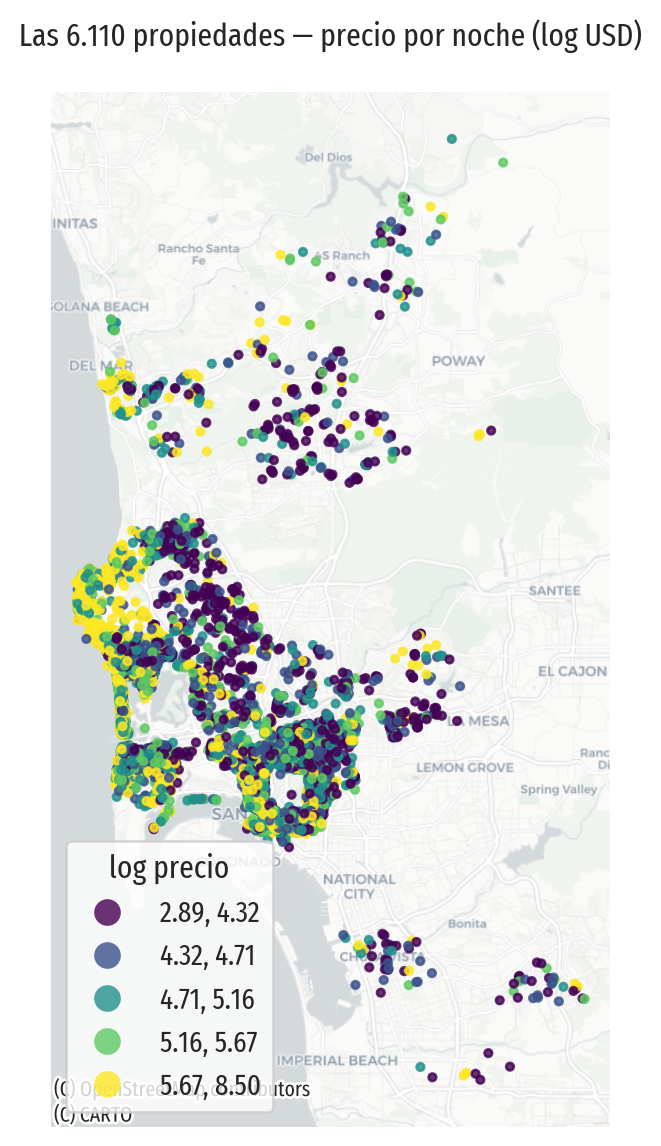

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
db.plot(column="log_price", scheme="Quantiles", k=5, cmap="viridis",
        markersize=8, alpha=0.8, ax=ax, legend=True,
        legend_kwds={"fmt": "{:.2f}", "loc": "lower left", "title": "log precio"})
cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Las 6.110 propiedades — precio por noche (log USD)", fontsize=12)
plt.savefig("img/clase11/01_muestra.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. La intuición: GWR son muchas regresiones locales

La idea de GWR se resume en un procedimiento. Para estimar los coeficientes **en el punto $i$**:

1. Situarse en el punto $i$.
2. Ponderar las demás propiedades por cercanía: las contiguas pesan mucho, las lejanas casi nada.
3. Ajustar un OLS ponderado con esos pesos.
4. Guardar esos coeficientes como $\beta(u_i, v_i)$: **el efecto local en $i$**.
5. Repetir para las 6.110 propiedades.

Resultado: 6.110 regresiones, cada una con su propio conjunto de coeficientes. La regla "los cercanos pesan más" es la **Primera Ley de la Geografía** de Tobler, la misma que sostiene a Moran y a todo el curso.

### Las dos piezas: kernel y bandwidth

El **kernel** es la función que convierte distancia en peso. Usamos el **bisquare**, que da peso a los vecinos dentro de un radio y **cero** afuera (recorte limpio):

$$w_{ij} = \left[1 - \left(\frac{d_{ij}}{b}\right)^2\right]^2 \quad \text{si } d_{ij} < b, \qquad w_{ij}=0 \text{ si no.}$$

El **bandwidth** $b$ es el radio: determina el grado de localidad de cada regresión. Es la decisión central de GWR:

- $b$ **pequeño** → cada regresión usa pocos vecinos → coeficientes que cambian mucho de un lugar a otro (mapa con detalle, pero ruidoso).
- $b$ **grande** → cada regresión usa casi todos los puntos → los coeficientes se parecen al OLS global (mapa suave, pero sin capturar variación local).

Veamos la forma del kernel para distintos bandwidths:

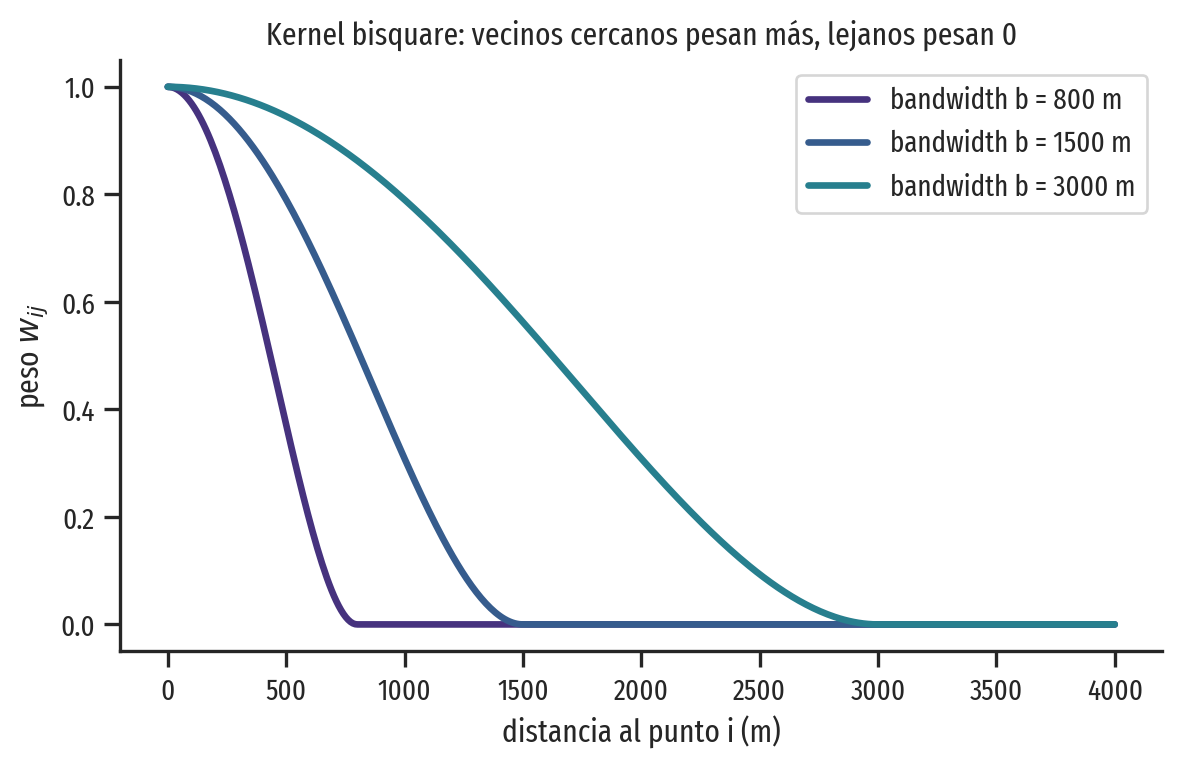

In [6]:
d = np.linspace(0, 4000, 400)
fig, ax = plt.subplots(figsize=(7, 4))
for b in [800, 1500, 3000]:
    w = np.where(d < b, (1 - (d / b) ** 2) ** 2, 0)
    ax.plot(d, w, lw=2.5, label=f"bandwidth b = {b} m")
ax.set_xlabel("distancia al punto i (m)")
ax.set_ylabel("peso $w_{ij}$")
ax.set_title("Kernel bisquare: vecinos cercanos pesan más, lejanos pesan 0")
ax.legend(); sns.despine()
plt.savefig("img/clase11/02_kernel.png", dpi=150, bbox_inches="tight")
plt.show()

### Bandwidth fijo vs adaptativo

- **Fijo**: el radio $b$ es el mismo en metros en toda la ciudad. Problema: donde hay pocas propiedades (zonas rurales) la regresión local no tiene suficientes datos.
- **Adaptativo**: en vez de fijar metros, fijamos un **número de vecinos** (los $k$ más cercanos). El radio se **adapta a la densidad**: se reduce donde hay muchas propiedades y se amplía donde son escasas. Para datos urbanos irregulares como Airbnb, es la opción sensata, y la que usaremos.

> **Conexión con la clase 02.** Esto es la **misma matriz $W$ de kernel** que vimos en pesos espaciales (`libpysal.weights.Kernel`): la misma función kernel (triangular / gaussian / bisquare…), el mismo `bandwidth` y el mismo `fixed=True/False` (fijo o adaptativo con $k$ vecinos). La diferencia es el **uso**: en la clase 02 construíamos **una** $W$ de kernel para todo el dataset; GWR toma **cada fila** de esa $W$ (los pesos del punto $i$ hacia sus vecinos, entre 0 y 1) y la usa como **pesos de un OLS local**, repitiendo punto por punto. GWR no es maquinaria nueva: es la $W$ de kernel que ya conocían, aplicada fila por fila.

## 4. ¿Qué bandwidth? Lo elige el AICc

No elegimos el bandwidth de forma arbitraria. `mgwr` lo busca **minimizando el AICc** (un criterio que premia el ajuste y castiga la complejidad, igual que el AIC pero corregido para muestras pequeñas). Prueba muchos valores con una búsqueda eficiente (golden section) y selecciona el óptimo.

Como elegimos kernel **adaptativo**, el bandwidth saldrá en **número de vecinos**, no en metros.

In [7]:
selector = Sel_BW(coords, y, X, fixed=False)   # fixed=False -> adaptativo (NN)
bw = selector.search(criterion="AICc")
print(f"Bandwidth óptimo (adaptativo) = {bw:.0f} vecinos más cercanos")
print(f"Es decir, cada regresión local usa los {bw:.0f} puntos más próximos de las 6.110 propiedades.")

Bandwidth óptimo (adaptativo) = 125 vecinos más cercanos
Es decir, cada regresión local usa los 125 puntos más próximos de las 6.110 propiedades.


### Opciones del bandwidth (para experimentar en tu proyecto)

Aquí usamos `AICc` + kernel `bisquare` + adaptativo, pero `mgwr` te deja cambiar **cuatro cosas**. Quedan documentadas para que pruebes en tu proyecto cuál conviene:

**1. Adaptativo vs Fijo** — `Sel_BW(..., fixed=...)`
- `fixed=False` (lo que usamos): el bandwidth es un **número de vecinos**; el radio se encoge donde hay densidad y se estira donde hay vacío. Mejor para datos urbanos irregulares.
- `fixed=True`: el bandwidth es una **distancia fija en metros**, igual en toda la zona.

**2. Kernel** — `Sel_BW(..., kernel=...)`: la forma de la ponderación por distancia.
- `'bisquare'` (lo que usamos): pesa a los vecinos dentro del radio y **0 afuera** (corte limpio).
- `'gaussian'`: decae suave, **nunca llega a 0** (todos los puntos pesan algo).
- `'exponential'`: decae exponencial, también sin corte.
- Ojo: el número del bandwidth **no es comparable** entre kernels.

**3. Criterio** — `.search(criterion=...)`: qué se minimiza al elegir el bandwidth.
- `'AICc'` (lo que usamos): equilibrio ajuste/complejidad, corregido para muestras pequeñas. El estándar.
- `'AIC'`: similar, sin la corrección.
- `'BIC'`: penaliza más la complejidad → bandwidth **más grande**, mapas más suaves (más cerca del OLS global).
- `'CV'`: validación cruzada → optimiza la **predicción**.

**4. Método de búsqueda** — `.search(search_method=...)`
- `'golden'` (lo que usamos): búsqueda eficiente (golden section).
- `'interval'`: grilla; defines `bw_min`, `bw_max` e `interval`.

> **Para tu proyecto:** corre la plantilla de abajo, cambia las opciones y compara el bandwidth resultante, el AICc y los mapas. No hay una única respuesta correcta: depende de tus datos y de tu pregunta.

In [8]:
# PLANTILLA para experimentar: cambia las tres opciones y observa el efecto.
usar_fijo   = False        # False = nº de vecinos (adaptativo) | True = metros (fijo)
mi_kernel   = "bisquare"   # "bisquare" | "gaussian" | "exponential"
mi_criterio = "AICc"       # "AICc" | "AIC" | "BIC" | "CV"

bw_exp  = Sel_BW(coords, y, X, fixed=usar_fijo, kernel=mi_kernel).search(criterion=mi_criterio)
res_exp = GWR(coords, y, X, bw_exp, fixed=usar_fijo, kernel=mi_kernel).fit()

unidad = "metros" if usar_fijo else "vecinos"
print(f"Opciones -> fixed={usar_fijo}, kernel={mi_kernel}, criterion={mi_criterio}")
print(f"  bandwidth = {bw_exp:.0f} {unidad}    AICc = {res_exp.aicc:.1f}    R2 = {res_exp.R2:.3f}")

Opciones -> fixed=False, kernel=bisquare, criterion=AICc
  bandwidth = 125 vecinos    AICc = 8192.9    R2 = 0.717


## 5. Ajustar GWR

Con el bandwidth elegido, ajustamos el modelo. La salida incluye elementos que el OLS no proporciona:

| Atributo | Qué es |
|---|---|
| `.params` | matriz $n \times (k{+}1)$: **un conjunto de coeficientes por punto** |
| `.localR2` | $R^2$ calculado **localmente** en cada punto |
| `.R2`, `.aicc` | ajuste global del modelo GWR |
| `.ENP` | número **efectivo** de parámetros (mide la complejidad real del modelo) |
| `.tvalues`, `.filter_tvals()` | significancia local (con corrección, sección 7) |

In [9]:
gwr = GWR(coords, y, X, bw, fixed=False)
res = gwr.fit()

print("                       OLS global      GWR")
print(f"R2                     {ols.rsquared:>7.3f}     {res.R2:>7.3f}")
print(f"AICc (menor = mejor)   {ols.aic:>7.1f}     {res.aicc:>7.1f}")
print(f"N de parametros        {len(variables)+1:>7d}     {res.ENP:>7.1f}  (efectivos)")

                       OLS global      GWR
R2                       0.552       0.717
AICc (menor = mejor)    9831.8      8192.9
N de parametros              5       537.7  (efectivos)


GWR aumenta el $R^2$ y **reduce sustancialmente el AICc**: se justifica el aumento de complejidad (de 5 parámetros a ~540 efectivos) porque el ajuste mejora de forma considerable. En otras palabras: **los coeficientes sí cambian en el espacio**; forzar uno solo para toda la ciudad desaprovechaba estructura espacial.

Pero el número resumen no es lo esencial de GWR. Lo esencial son los **mapas**.

## 6. Mapas de coeficientes locales

`res.params` tiene una columna por variable (más la constante). Cada columna es **un mapa**: cómo cambia el efecto de esa variable a lo largo de San Diego. Esto es lo que ningún modelo global de las clases 08-09 podía darnos.

In [10]:
# Guardamos cada coeficiente local como columna del GeoDataFrame
# params: columna 0 = intercepto, 1..k = variables
for j, v in enumerate(variables):
    db[f"b_{v}"] = res.params[:, j + 1]

db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry,b_accommodates,b_bedrooms,b_bathrooms,b_d2balboa
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (487849.961 3624022.580),0.173910,0.387926,0.144759,-0.565226
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (476352.113 3627393.256),0.050303,0.191157,0.141995,0.979617
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (486772.302 3623943.385),0.575430,0.194332,-0.100864,-1.233364
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (485725.689 3643659.514),0.521010,-0.015036,0.165356,0.172768
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (479510.620 3622708.972),0.283663,0.368741,-0.008804,1.800831


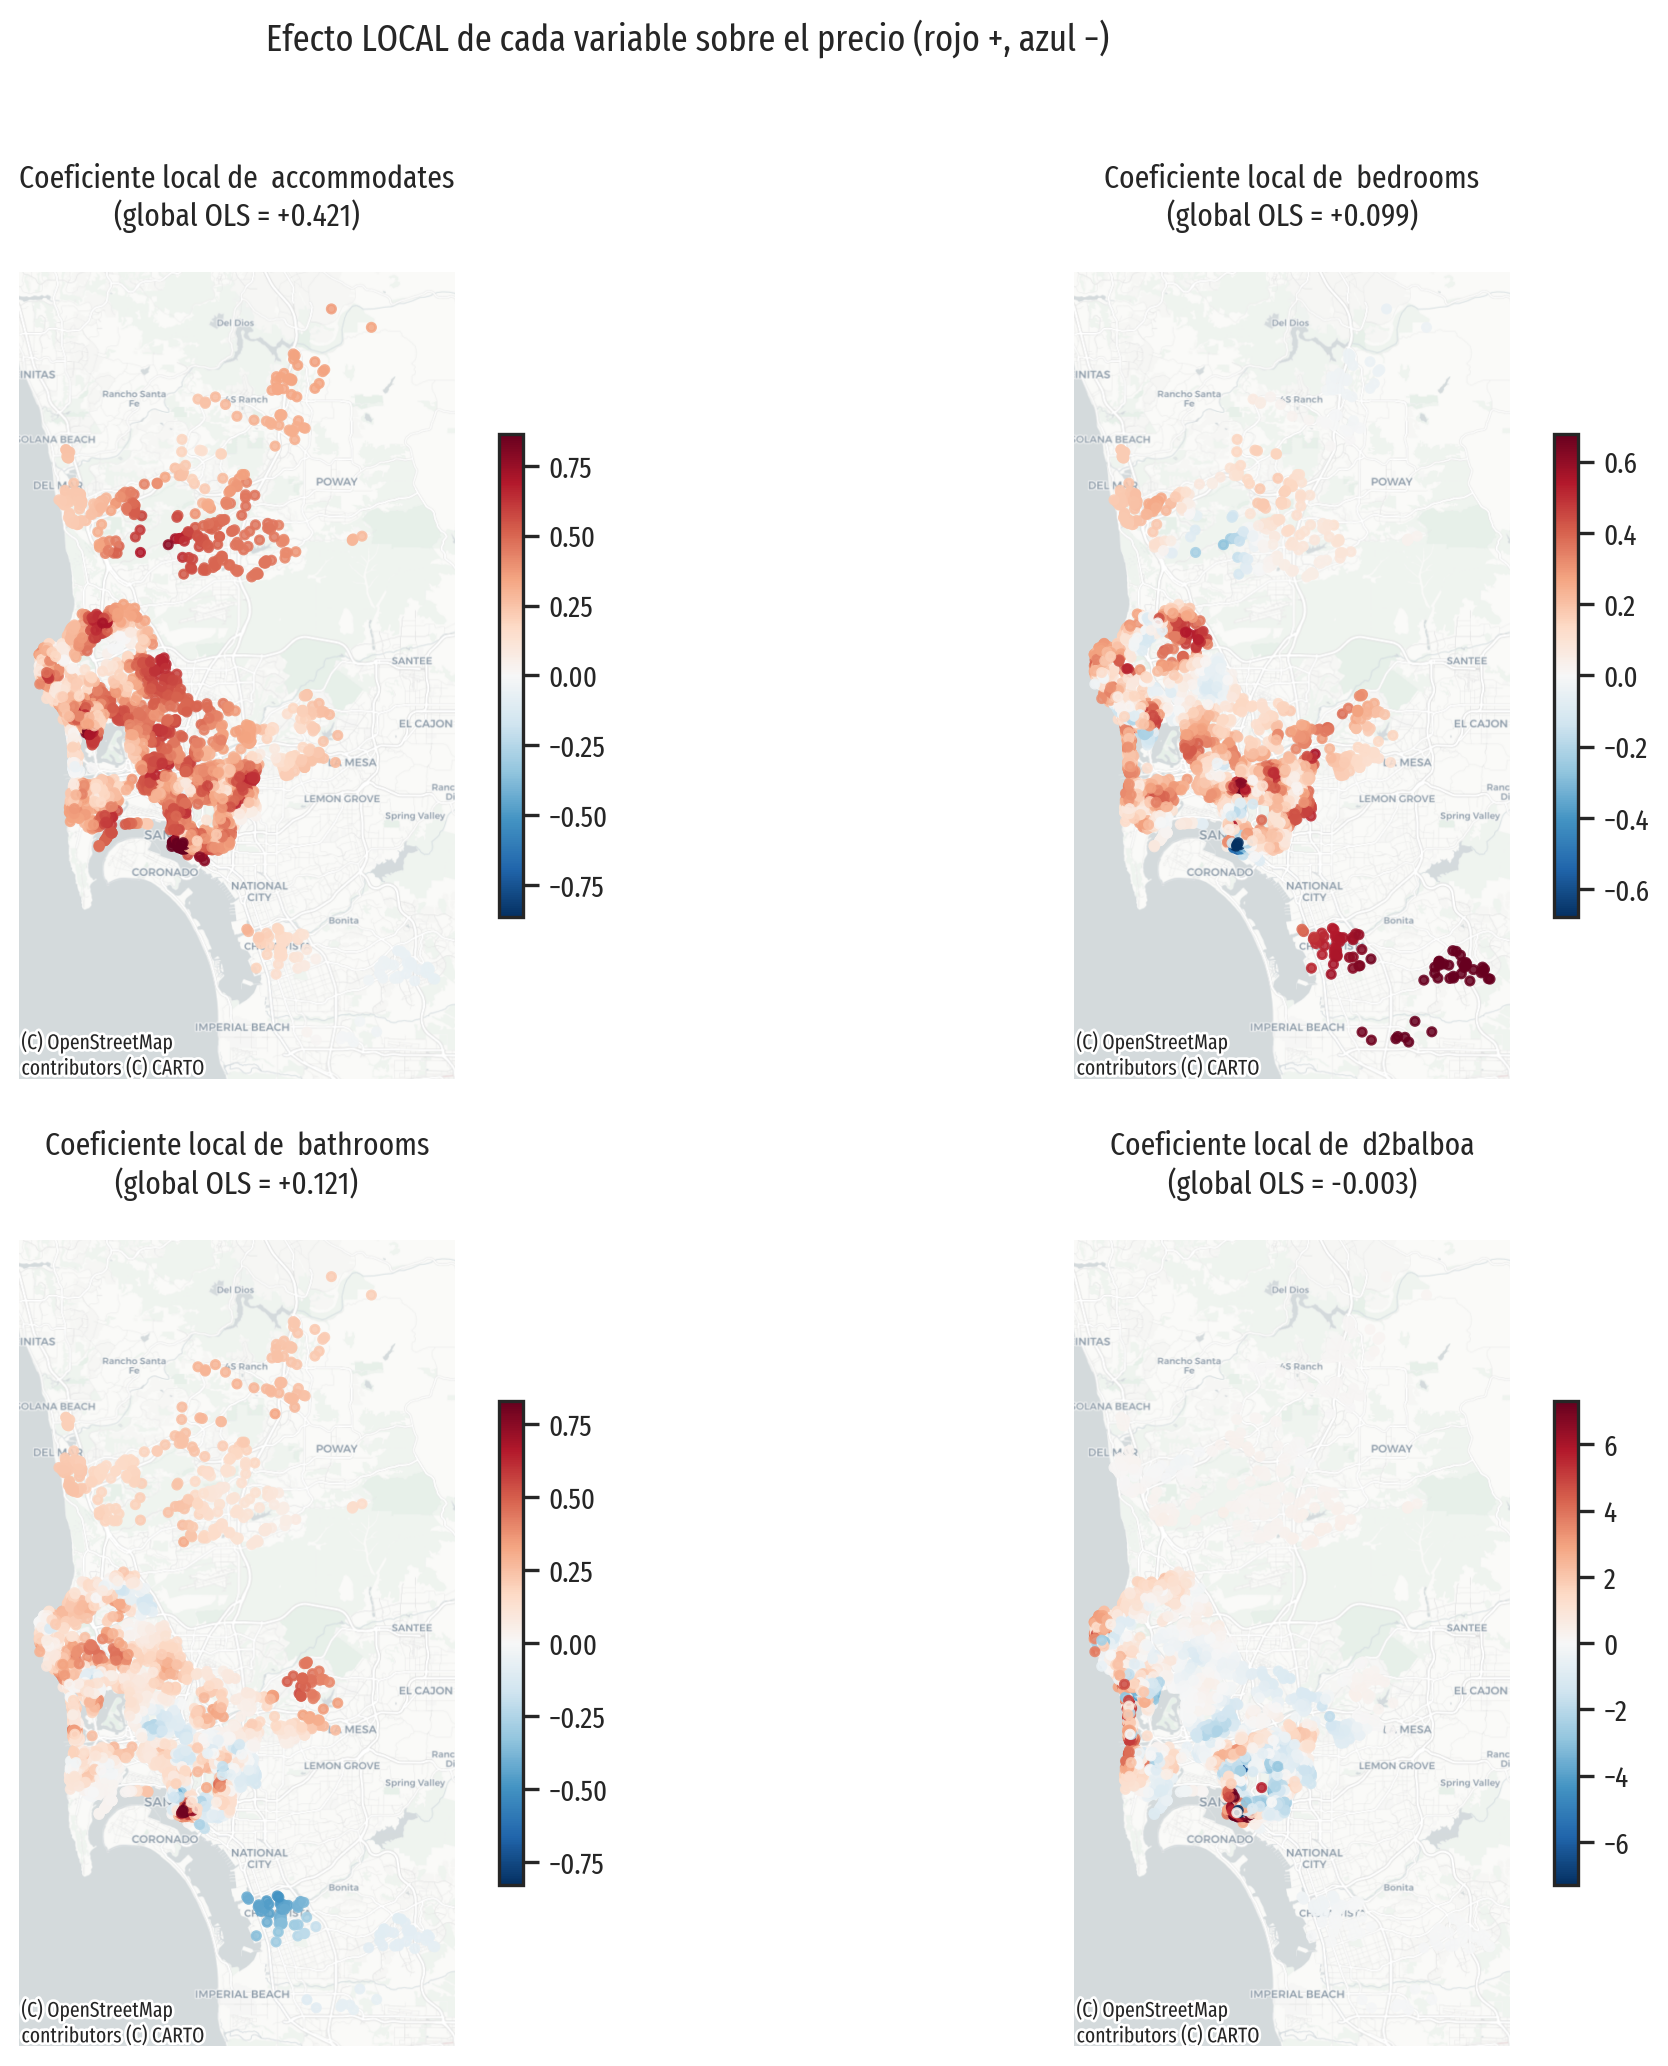

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, v in zip(axes.ravel(), variables):
    lim = np.abs(db[f"b_{v}"]).quantile(0.98)
    db.plot(column=f"b_{v}", cmap="RdBu_r", vmin=-lim, vmax=lim,
            markersize=10, alpha=0.85, ax=ax, legend=True,
            legend_kwds={"shrink": 0.6})
    cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
    ax.set_axis_off()
    ax.set_title(f"Coeficiente local de  {v}\n(global OLS = {global_betas[v]:+.3f})",
                 fontsize=12)
fig.suptitle("Efecto LOCAL de cada variable sobre el precio (rojo +, azul −)",
             fontsize=14, y=0.99)
plt.savefig("img/clase11/03_coeficientes.png", dpi=150, bbox_inches="tight")
plt.show()

Cómo leer estos mapas (rojo = efecto positivo, azul = negativo, intensidad = magnitud):

- **`accommodates`** es positivo en casi toda la ciudad (más capacidad, más caro), pero **no con la misma fuerza**: hay zonas donde la capacidad es determinante y otras donde su efecto es marginal.
- **`d2balboa`** es el caso más ilustrativo: el OLS estimó un efecto cercano a cero, pero el mapa muestra zonas claramente rojas y zonas azules. El efecto **existe y cambia de signo según la zona**; al promediarlo sobre toda la ciudad, los positivos y negativos se cancelan y dan ~0. El coeficiente global cercano a cero no indicaba ausencia de efecto, sino efectos opuestos que se compensan entre zonas.
- Donde `bedrooms` y `bathrooms` cambian de signo, suele ser **colinealidad local**: con pocos vecinos, dos variables correlacionadas se "reparten" el efecto de forma inestable. Es un riesgo real de GWR, no necesariamente un patrón geográfico real (volvemos a esto al cierre).

### El mapa de $R^2$ local: ¿dónde funciona el modelo?

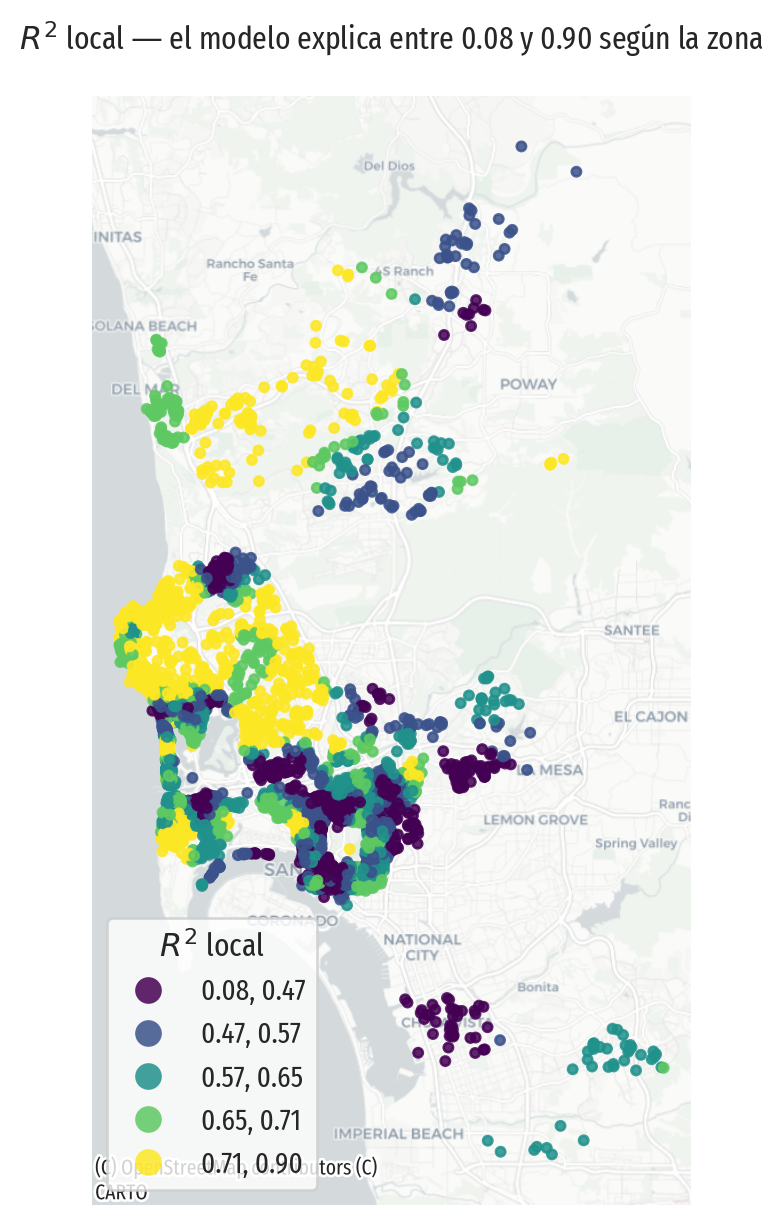

In [12]:
db["localR2"] = res.localR2

fig, ax = plt.subplots(figsize=(7.5, 7.5))
db.plot(column="localR2", cmap="viridis", scheme="Quantiles", k=5,
        markersize=12, alpha=0.85, ax=ax, legend=True,
        legend_kwds={"fmt": "{:.2f}", "loc": "lower left", "title": "$R^2$ local"})
cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"$R^2$ local — el modelo explica entre "
             f"{db['localR2'].min():.2f} y {db['localR2'].max():.2f} según la zona",
             fontsize=12)
plt.savefig("img/clase11/04_localR2.png", dpi=150, bbox_inches="tight")
plt.show()

El $R^2$ local es un diagnóstico que el OLS no da: nos dice **dónde el modelo predice bien y dónde falla**. Las zonas oscuras (R² bajo) son candidatas a tener variables omitidas importantes (vista, ruido, un atractivo turístico que no medimos). Es una guía concreta de dónde conviene buscar más datos.

## 7. ¿Dónde es significativo el efecto?

Tenemos un coeficiente local en cada punto. Pero un coeficiente nunca viene solo: trae también su **error estándar**, que mide cuánta **incertidumbre** hay en esa estimación. La pregunta es si el efecto es lo bastante grande como para no confundirse con ese ruido.

Lo medimos con una división simple, **señal sobre ruido**:

$$t \;=\; \frac{\text{coeficiente}}{\text{su error}} \;=\; \frac{\hat\beta}{SE(\hat\beta)}$$

- Si el coeficiente es **grande comparado con su error**, el efecto es real: lo llamamos **significativo**.
- Si el coeficiente es **del mismo tamaño que su error**, podría ser solo azar: no podemos distinguirlo de cero.

Un coeficiente es significativo donde ese cociente $|t|$ supera cierto **umbral** (el valor a partir del cual lo consideramos "grande").

**El umbral sube porque hacemos muchas pruebas a la vez.** Como estimamos el coeficiente en los 6.110 puntos, hacemos 6.110 comparaciones simultáneas; con tantas, algunas se verían "grandes" solo por azar (**comparaciones múltiples**). Por eso se usa un umbral **corregido**, más exigente, que crece con la cantidad de pruebas: en nuestros datos sube hasta $\approx 3.5$. `mgwr` lo entrega con `res.critical_tval()`.

**Cómo se usa:** se compara el $|t|$ de cada punto con `res.critical_tval()`. Donde lo supera, el efecto es significativo; donde no, no podemos distinguirlo de cero.

Visualmente: el **0 significa "la variable no influye"**. Un coeficiente es **significativo** si su barra de error **no llega a tocar el 0**; si la barra **pisa el 0**, el efecto podría ser nulo (azar).

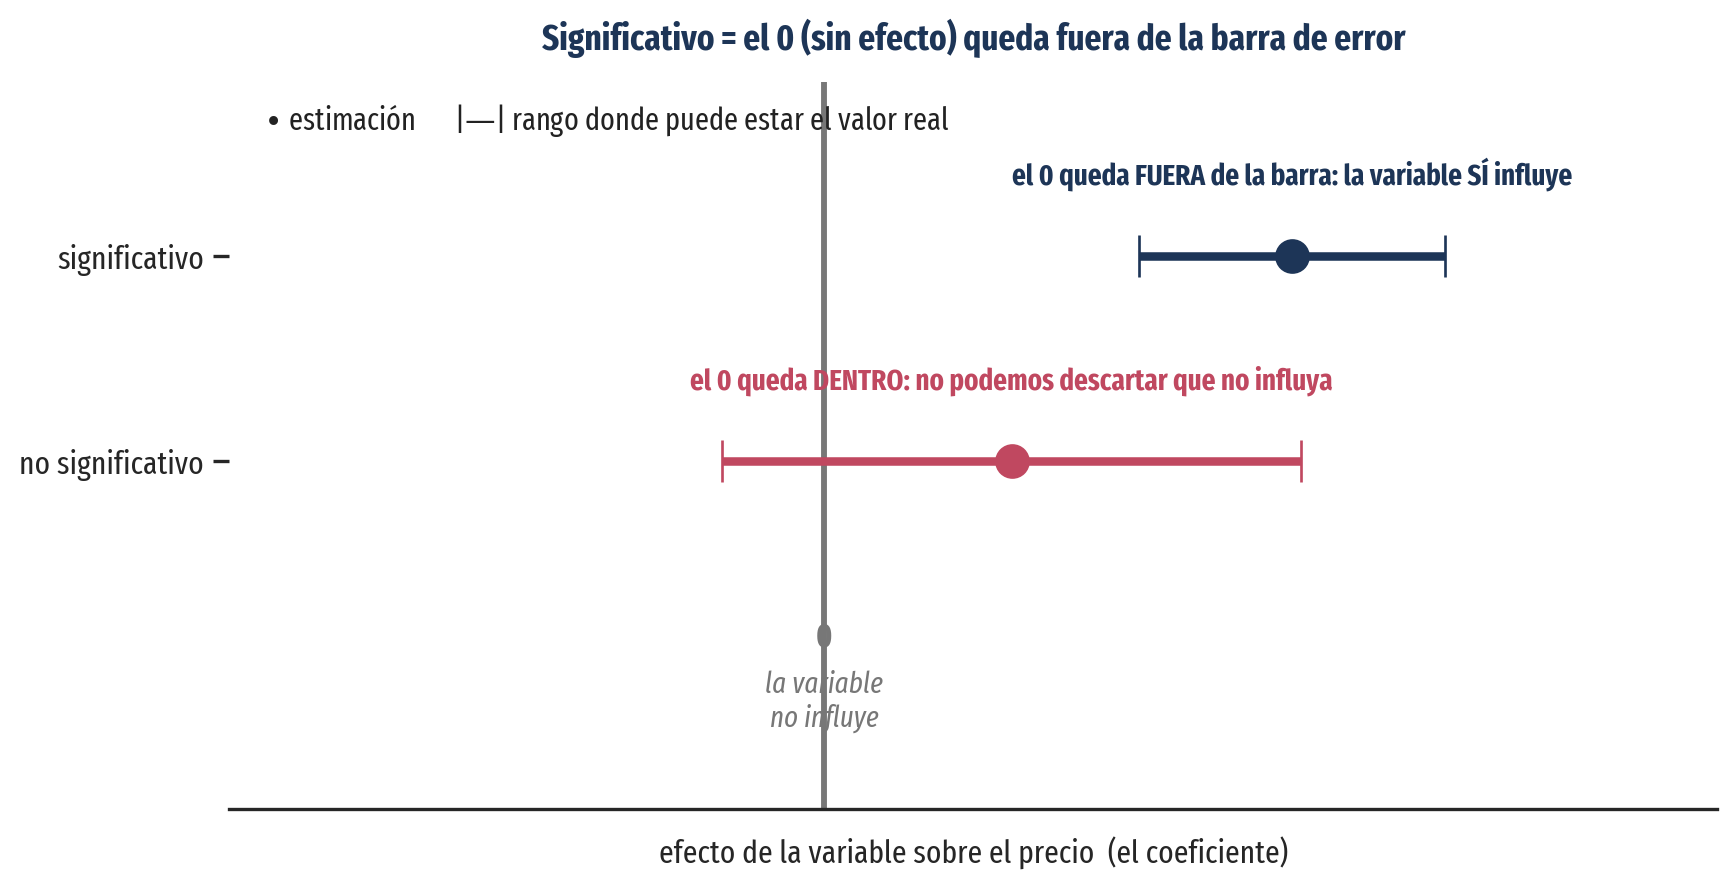

In [13]:
# Significativo = el 0 (sin efecto) queda FUERA de la barra de error.
# El 0 marca "la variable no influye"; la barra = incertidumbre del coeficiente.
casos = [
    dict(y=1, beta=0.55, margen=0.18, col="#1D3557",
         nota="el 0 queda FUERA de la barra: la variable SÍ influye"),
    dict(y=0, beta=0.22, margen=0.34, col="#C04860",
         nota="el 0 queda DENTRO: no podemos descartar que no influya"),
]
fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.axvline(0, color="#777777", lw=2.2)
ax.text(0, -0.78, "0", ha="center", va="top", fontsize=12, color="#777777", weight="bold")
ax.text(0, -1.02, "la variable\nno influye", ha="center", va="top",
        fontsize=11, color="#777777", style="italic")
for c in casos:
    ax.errorbar(c["beta"], c["y"], xerr=c["margen"], fmt="o", color=c["col"], ecolor=c["col"],
                elinewidth=3.2, capsize=8, ms=12, zorder=3)
    ax.text(c["beta"], c["y"] + 0.32, c["nota"], ha="center", va="bottom",
            fontsize=11, color=c["col"], weight="bold")
ax.set_yticks([1, 0]); ax.set_yticklabels(["significativo", "no significativo"], fontsize=12)
ax.set_xlim(-0.7, 1.05); ax.set_ylim(-1.7, 1.85); ax.set_xticks([])
ax.set_xlabel("efecto de la variable sobre el precio  (el coeficiente)", fontsize=12, labelpad=10)
ax.text(-0.66, 1.62, r"$\bullet$ estimación      |—| rango donde puede estar el valor real",
        fontsize=11.5, color="#222222")
ax.set_title("Significativo = el 0 (sin efecto) queda fuera de la barra de error",
             fontsize=13.5, color="#1D3557", weight="bold", pad=12)
sns.despine(left=True)
plt.tight_layout()
plt.savefig("img/clase11/06_senal_ruido.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# El umbral t: el de siempre (1.96) vs el corregido por hacer miles de tests a la vez
umbral = res.critical_tval()
print(f"Umbral t sin corregir (un solo test) : 1.96")
print(f"Umbral t corregido ({len(db)} tests)   : {umbral:.2f}")

# res.tvalues es una matriz: una FILA por punto, una COLUMNA por variable.
# La columna 0 es el intercepto, por eso d2balboa va en su posicion + 1.
col_d2balboa = variables.index("d2balboa") + 1
t_local = res.tvalues[:, col_d2balboa]      # el t de d2balboa en cada punto

# Significativo = el |t| local supera el umbral corregido
db["sig_d2balboa"] = np.abs(t_local) > umbral

frac = db["sig_d2balboa"].mean()
print(f"\nd2balboa es significativa en {frac:.0%} de los {len(db)} puntos.")

# (Atajo equivalente de mgwr: res.filter_tvals() pone en 0 los t no
#  significativos; aqui lo hacemos paso a paso para que se vea la logica.)

Umbral t sin corregir (un solo test) : 1.96
Umbral t corregido (6110 tests)   : 3.50

d2balboa es significativa en 2% de los 6110 puntos.


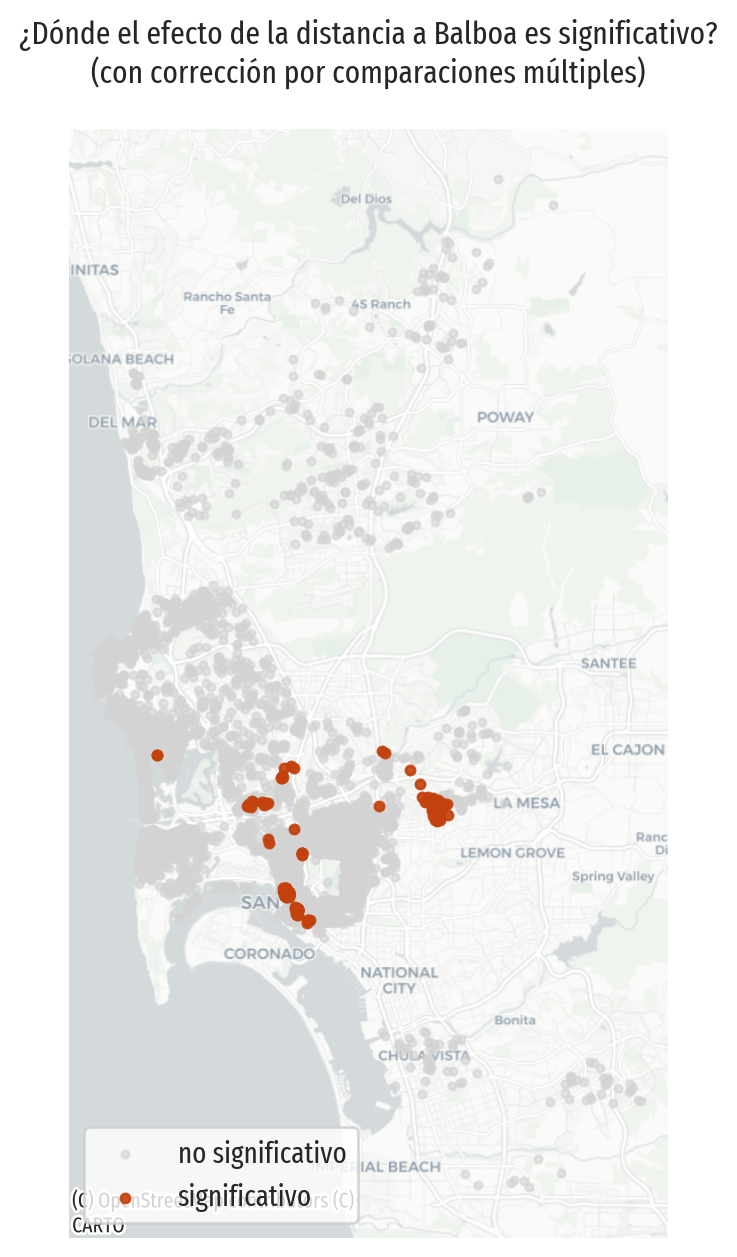

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 7.5))
db[~db["sig_d2balboa"]].plot(ax=ax, color="lightgrey", markersize=8,
                             alpha=0.6, label="no significativo")
db[db["sig_d2balboa"]].plot(ax=ax, color="#c2410c", markersize=12,
                            alpha=0.9, label="significativo")
cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.legend(loc="lower left")
ax.set_title("¿Dónde el efecto de la distancia a Balboa es significativo?\n"
             "(con corrección por comparaciones múltiples)", fontsize=12)
plt.savefig("img/clase11/05_significancia.png", dpi=150, bbox_inches="tight")
plt.show()

Este mapa es más riguroso: la distancia a Balboa **no** importa en todas partes. Hay zonas donde el efecto es real y zonas donde no podemos distinguirlo de cero. Reportar el coeficiente local **sin** este filtro sería sobre-interpretar el ruido.

## 8. Coeficientes locales vs global: la distribución

Otra forma de ver lo mismo: para cada variable, dibujamos la **distribución** de sus 6.110 coeficientes locales y la comparamos con la única cifra del OLS (línea negra). Si la caja es ancha, el efecto varía mucho en el espacio; si el global cae lejos del centro, el promedio inducía a error.

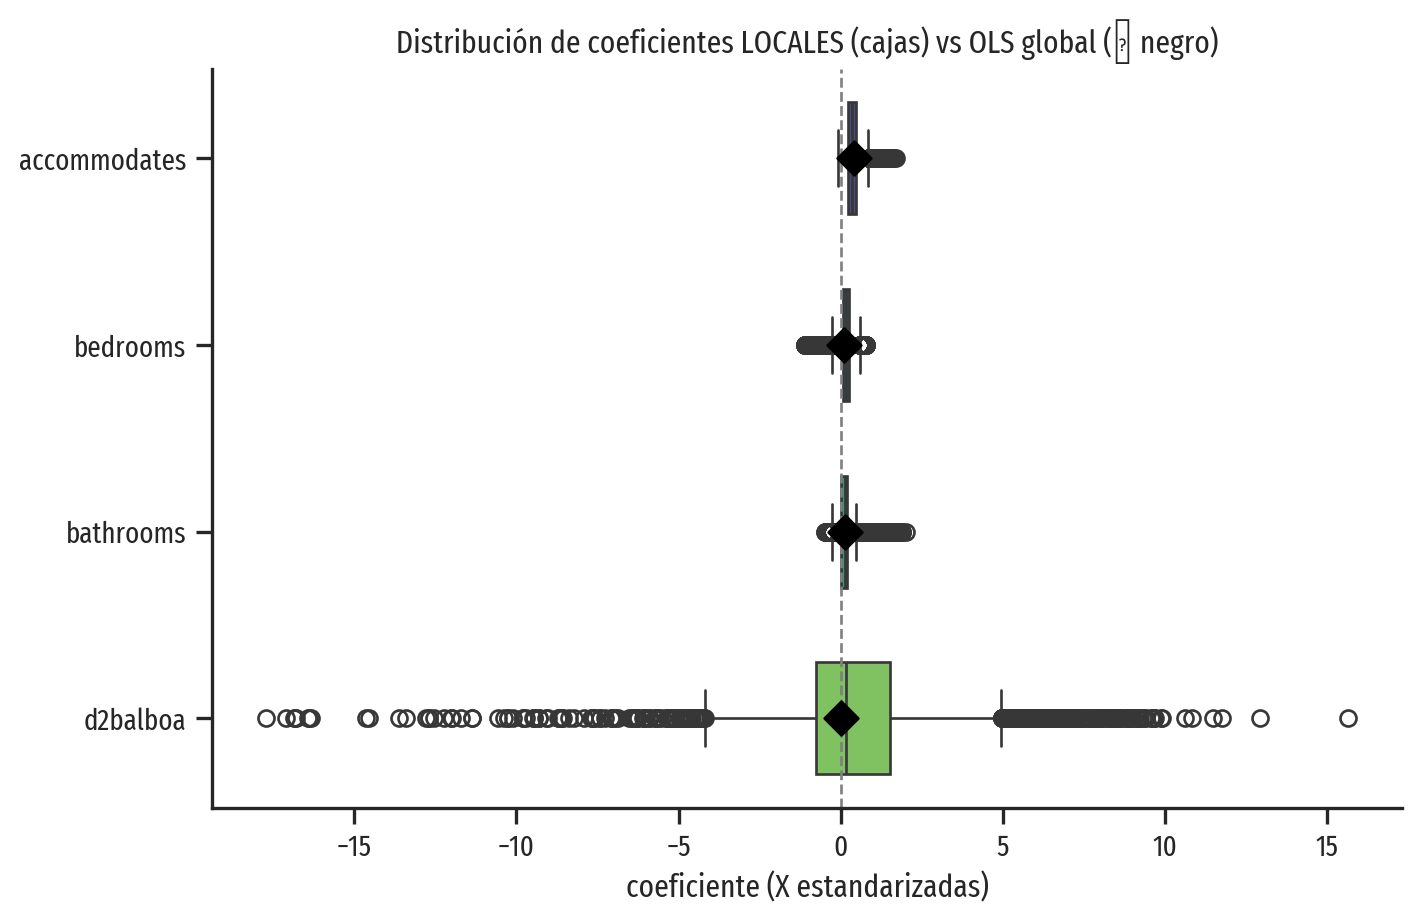

In [16]:
local_df = pd.DataFrame({v: db[f"b_{v}"] for v in variables})

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=local_df, orient="h", palette="viridis", ax=ax, width=0.6)
for i, v in enumerate(variables):
    ax.scatter(global_betas[v], i, color="black", zorder=5, s=80, marker="D")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("coeficiente (X estandarizadas)")
ax.set_title("Distribución de coeficientes LOCALES (cajas) vs OLS global (♦ negro)")
sns.despine()
plt.savefig("img/clase11/06_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

La lectura: el coeficiente global (♦) es apenas **el promedio** de una distribución que en varias variables es ancha y hasta **cruza el cero**. GWR no contradice al OLS: lo **descompone**. Donde la caja cruza el cero, el efecto cambia de signo según el barrio, algo que un solo número jamás podría comunicar.

## 9. Comparación final: las cinco formas de incorporar el espacio

Cerramos la trilogía de regresión espacial (clases 08, 09 y hoy) con el cuadro completo:

| Modelo | Qué agrega | Pregunta que responde | El espacio es… |
|---|---|---|---|
| **OLS** | nada | ¿efecto promedio de cada atributo? | ignorado |
| **SLX** | $WX\gamma$ | ¿importan los atributos de los vecinos? | contexto |
| **SEM** | $\lambda Wu$ | ¿hay variables territoriales omitidas? | ruido a corregir |
| **SAR** | $\rho Wy$ | ¿se contagia el precio entre vecinos? | contagio a corregir |
| **GWR** | $\beta(u,v)$ | **¿dónde** cada atributo pesa más o menos? | **objeto de estudio** |

**SLX/SEM/SAR vienen de la econometría espacial**: el espacio es una complicación que hay que modelar para que los coeficientes **globales** sean válidos. **GWR viene de la geografía cuantitativa**: el espacio es la respuesta que buscamos, y el entregable es un mapa.

A continuación pasamos del cuadro conceptual a la comparación empírica: ajustamos los cinco modelos sobre los mismos datos y vemos cuál ajusta mejor.

### Comparación empírica: ajustamos los cinco modelos

Para comparar de forma justa, ajustamos **los cinco modelos sobre exactamente los mismos datos**: misma $y$ (`log_price`), las mismas cuatro variables estandarizadas, las 6.110 propiedades y la misma $W$ (KNN con $k=20$). Solo así los números son comparables.

Una aclaración sobre estimación: en las clases 08-09 ajustamos SEM y SAR con los estimadores **GMM** (`GM_Error_Het`, `GM_Lag`), robustos a heterocedasticidad. Aquí usamos las versiones de **máxima verosimilitud** (`ML_Error`, `ML_Lag`), porque son las que entregan un **AIC comparable** con OLS y GWR. Los coeficientes son casi idénticos; cambia solo cómo se estiman.

In [17]:
w = weights.KNN.from_array(coords, k=20, silence_warnings=True)
w.transform = "r"

def moran_resid(u):
    m = Moran(np.asarray(u).flatten(), w)
    return m.I, m.p_sim

# OLS y SLX
m_ols = spreg.OLS(y, X, w=w, spat_diag=True)
X_slx = np.column_stack([X] + [weights.lag_spatial(w, X[:, i]) for i in range(X.shape[1])])
m_slx = spreg.OLS(y, X_slx, w=w)

# SEM y SAR por maxima verosimilitud (AIC comparable con OLS y GWR)
m_sem = spreg.ML_Error(y, X, w=w)
m_sar = spreg.ML_Lag(y, X, w=w)

# GWR: ya ajustado en la seccion 5 (res)

ML_Error
ML_Lag


In [18]:
filas = []
def fila(nombre, ajuste, aic, u, clave=""):
    I, p = moran_resid(u)
    filas.append({"Modelo": nombre, "R2 / pseudo-R2": round(ajuste, 3),
                  "AIC": round(aic, 1), "Moran I resid.": round(I, 4),
                  "p (Moran)": round(p, 3), "Termino clave": clave})

fila("OLS", m_ols.r2,  m_ols.aic, m_ols.u, "—")
fila("SLX", m_slx.r2,  m_slx.aic, m_slx.u, "gamma (lags de X)")
# SEM: el residuo relevante es el FILTRADO (e_filtered = epsilon), no el crudo u,
# que por construccion todavia arrastra la estructura espacial lambda*Wu (ver clase 09).
fila("SEM", m_sem.pr2, m_sem.aic, m_sem.e_filtered, f"lambda = {m_sem.betas[-1,0]:+.3f}")
fila("SAR", m_sar.pr2, m_sar.aic, m_sar.u, f"rho = {m_sar.betas[-1,0]:+.3f}")
fila("GWR", res.R2,    res.aic,   res.resid_response, f"bw = {bw:.0f} vec.")

pd.DataFrame(filas).set_index("Modelo")

,R2 / pseudo-R2,AIC,Moran I resid.,p (Moran),Termino clave
Modelo,,,,,
OLS,0.552,9831.8,0.1937,0.001,—
SLX,0.588,9325.8,0.1320,0.001,gamma (lags de X)
SEM,0.549,8867.2,-0.0107,0.003,lambda = +0.679
SAR,0.621,8874.2,0.0212,0.001,rho = +0.479
GWR,0.717,8088.5,-0.0126,0.001,bw = 125 vec.


### Cómo leer la tabla (las dos columnas que deciden)

No hay un único "mejor": depende de qué métrica se priorice. Las dos que en realidad deciden son:

- **AIC (menor = mejor).** Premia el ajuste y penaliza la complejidad. Es la medida estándar para comparar modelos sobre los mismos datos. **GWR es claramente superior**, porque deja que cada coeficiente se adapte localmente: paga muchos parámetros, pero el ajuste lo compensa.
- **Moran's I de los residuos (más cerca de 0 = mejor).** Mide cuánta estructura espacial quedó **sin explicar**. El OLS deja un Moran's I claramente positivo y significativo (~0.19: autocorrelación residual que viola los supuestos). SLX lo reduce parcialmente (~0.13). SEM, SAR y GWR lo dejan **prácticamente en cero**: cada uno, a su manera, eliminó la dependencia espacial.

> **Detalle técnico (igual que en clase 09):** para SEM reportamos el Moran de los **residuos filtrados** (`e_filtered` $= \varepsilon$), no los crudos (`u`). Los crudos de SEM, por construcción, **todavía** arrastran el término $\lambda W u$, así que su Moran resulta alto y engañoso (~0.22). El residuo que realmente debe quedar como ruido blanco es el filtrado.

El $R^2$ / pseudo-$R^2$ se interpreta con cautela: el de OLS/SLX (ajuste clásico), el de SEM/SAR (pseudo-$R^2$) y el de GWR **no están en la misma escala**, así que sirve como referencia, no como criterio decisivo. El AIC, en cambio, sí es comparable entre todos.

### Veredicto: depende de la pregunta

| Si el objetivo es… | El más adecuado es… | Por qué |
|---|---|---|
| **Mejor ajuste / menor AIC** sobre estos datos | **GWR** | adapta los coeficientes a cada zona; AIC muy por debajo del resto |
| **Eliminar la autocorrelación** de los residuos | **SEM** (o SAR) | diseñados para ello; dejan Moran's I ≈ 0 |
| **Estimar un efecto global válido** (inferencia clásica) | **SEM / SAR** | corrigen la dependencia y dan coeficientes y p-valores confiables |
| **Determinar dónde** cada variable pesa más | **GWR** | es el único que produce un mapa por coeficiente |
| **Modelo base de referencia** | **OLS** | punto de partida; si sus residuos ya son ruido, no se requiere más |

**La conclusión honesta:** "mejor" no es una propiedad del modelo, sino de la **pregunta de investigación**.

- Para **entender el territorio** (¿dónde importa la cercanía a Balboa?, ¿dónde falla el modelo?), GWR es la mejor opción: su salida *es* un mapa.
- Para **un valor defendible** del efecto de un dormitorio en San Diego, controlando la dependencia espacial, conviene usar **SEM o SAR**.
- Si los residuos del **OLS** ya no muestran autocorrelación (Moran's I ≈ 0), no se requería nada de esto: el modelo simple basta. Por eso el diagnóstico de la clase 08 (Moran sobre residuos) es siempre el primer paso.

GWR destaca en **ajuste y exploración espacial**; SEM y SAR, en **inferencia global**. No son excluyentes: responden preguntas distintas.

### La frase modelo de GWR

> *"El efecto de la distancia a Balboa Park sobre el precio no es constante en San Diego: es significativamente positivo en la costa, se desvanece en el interior, y el modelo explica mejor el precio en unas zonas que en otras (R² local de 0.08 a 0.90)."*

### Cuándo usar GWR (y cuándo no)

**Conviene usarlo cuando** la pregunta es explícitamente *dónde* (¿dónde pesa más esta variable?, ¿es estable la relación en el territorio?)

**Precauciones:**
- **Colinealidad local.** Con pocos vecinos, variables correlacionadas dan coeficientes inestables (lo vimos en `bedrooms`/`bathrooms`). Conviene verificar si un patrón es geográfico o un artefacto.
- **No es un modelo predictivo** en el sentido clásico: está pensado para *entender* la variación espacial, no para predecir en sitios nuevos.
- **Comparaciones múltiples**: usar siempre el $t$ corregido (`res.critical_tval()`), nunca un umbral sin corregir.
- **MGWR** (Fotheringham et al., 2017) es la extensión moderna: deja que **cada variable tenga su propio bandwidth** (algunas relaciones son muy locales, otras casi globales). En `mgwr` se ajusta con la clase `MGWR`; es el siguiente paso natural si el tema resulta de interés.

## 10. Cierre del curso

Con GWR cerramos el recorrido completo de INF-497. Conviene revisarlo en conjunto, porque hoy se usan casi todos los temas:

- **Datos espaciales y CRS** (clases 00-01): hoy *tuvimos* que reproyectar a metros para que las distancias tuvieran sentido.
- **Pesos espaciales** (clase 02): el kernel de GWR es una matriz de pesos $W$, pero **continua y local** en vez de binaria.
- **Autocorrelación** (clases 04-05): la razón de ser de toda la regresión espacial; Tobler sigue siendo el motor.
- **Desigualdad y regionalización** (clases 06-07): la idea de que el territorio **no es homogéneo**, que aquí se vuelve no-estacionariedad de los coeficientes.
- **Regresión espacial** (clases 08-09-11): de corregir el espacio (SEM/SAR) a mapear el espacio (GWR).
- **Feature engineering** (clase 10): de dónde provienen variables como `d2balboa`.

La gran idea del curso, una vez más: **en datos espaciales la ubicación no es una columna más**. Cambia cómo medimos, cómo modelamos y qué preguntas podemos responder. GWR es quizás la expresión más pura de eso: el resultado del modelo **es un mapa**.

